In [1]:
import pandas as pd

df = pd.read_csv("FINALDS.csv")

df = df.drop(columns=["ClientId"])

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

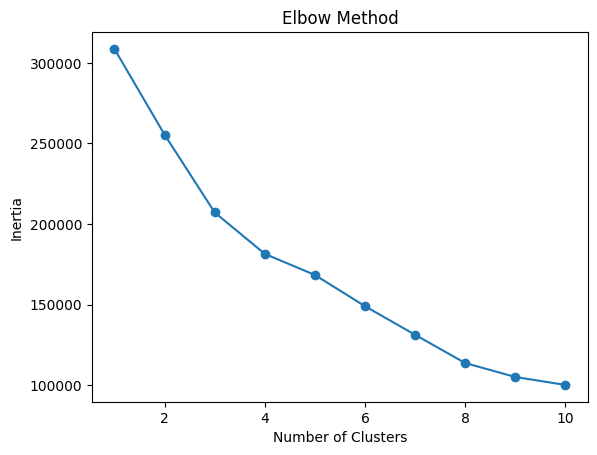

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

In [5]:
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)

         total_accounts  total_transactions  total_amount  avg_transaction  \
cluster                                                                      
0              1.043541         1012.473192  4.784276e+06      5429.952415   
1              1.030915           12.675998  3.494366e+05     28928.864845   
2              1.113043          147.647826  3.895765e+07    512348.015991   
3              1.040038           85.972185  1.063659e+06     22342.610363   

         max_transaction  min_transaction  recency_days  activity_span  \
cluster                                                                  
0           1.942620e+05         1.353534     67.972292     290.235696   
1           1.069050e+05        56.764615    135.555258     173.666180   
2           3.522929e+06       218.146565     97.482609     209.526087   
3           1.603782e+05        73.863704     77.273051     264.676131   

         transactions_per_day  active_days     amount_std    amount_var  
cluster     

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Create dataframe for visualization
import pandas as pd

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

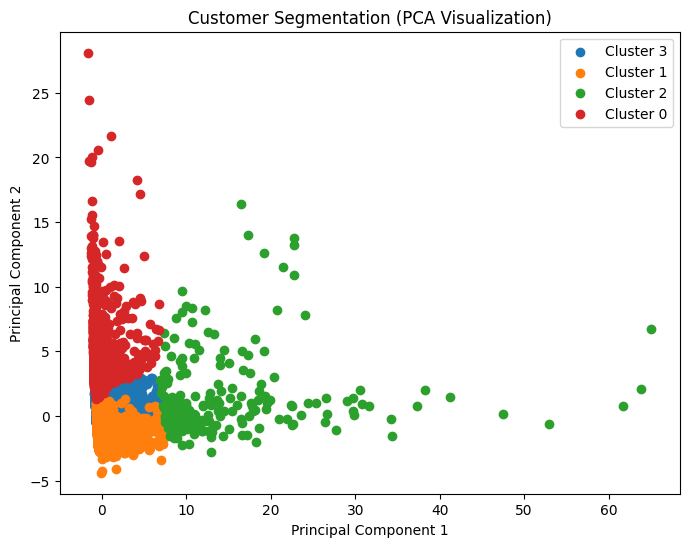

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segmentation (PCA Visualization)')
plt.legend()
plt.show()

In [8]:
import numpy as np

# distance from cluster center
distances = kmeans.transform(scaled_data)

# distance of each point from its assigned cluster
df['distance'] = np.min(distances, axis=1)

# mark top anomalies
threshold = np.percentile(df['distance'], 99)

df['anomaly'] = df['distance'] > threshold

In [9]:
df[df['anomaly'] == True].head()

,total_accounts,total_transactions,total_amount,avg_transaction,max_transaction,min_transaction,recency_days,activity_span,transactions_per_day,active_days,amount_std,amount_var,cluster,distance,anomaly
72,3,43,287917.10,6695.7465,13500.0,17.7,78,278,1.720000,25,4402.416674,1.938127e+07,3,9.261115,True
81,3,259,2490637.10,9616.3594,199000.0,1.0,67,297,1.918519,135,27409.367390,7.512734e+08,3,9.356157,True
110,3,119,2636428.10,22154.8579,250000.0,1.0,81,276,1.586667,75,43244.749680,1.870108e+09,3,9.256283,True
114,6,794,17266138.49,21745.7663,729600.0,1.0,66,298,3.336134,238,66459.147090,4.416818e+09,0,23.464345,True
191,3,69,5728443.20,83020.9159,345000.0,5.9,75,283,1.682927,41,85979.599020,7.392491e+09,3,9.319111,True


In [10]:
df['anomaly'].value_counts()

anomaly
False    25465
True       258
Name: count, dtype: int64

In [11]:
high_amount_threshold = df['avg_transaction'].quantile(0.99)
high_variance_threshold = df['amount_std'].quantile(0.99)

df['high_amount_flag'] = df['avg_transaction'] > high_amount_threshold
df['high_variance_flag'] = df['amount_std'] > high_variance_threshold

df['risk_score'] = (
    df['anomaly'].astype(int) +
    df['high_amount_flag'].astype(int) +
    df['high_variance_flag'].astype(int)
)

In [12]:
df['suspicious'] = df['risk_score'] >= 2

In [13]:
df['suspicious'].value_counts()

suspicious
False    25512
True       211
Name: count, dtype: int64

In [14]:
df.groupby('suspicious').mean()

,total_accounts,total_transactions,total_amount,avg_transaction,max_transaction,min_transaction,recency_days,activity_span,transactions_per_day,active_days,amount_std,amount_var,cluster,distance,anomaly,high_amount_flag,high_variance_flag,risk_score
suspicious,,,,,,,,,,,,,,,,,,
False,1.036218,152.152634,1.233781e+06,23656.774813,1.434416e+05,48.888852,104.384917,223.612104,1.809905,46.740553,35365.91583,5.105903e+09,1.706648,1.477457,0.007408,0.002234,0.002117,0.011759
True,1.094787,72.862559,2.908727e+07,559513.243816,3.196556e+06,1297.126919,102.834123,190.573460,1.977348,27.843602,857434.53717,9.450123e+11,1.962085,11.148734,0.327014,0.952607,0.966825,2.246445


In [15]:
import joblib

joblib.dump(kmeans, "kmeans.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [16]:
import joblib
import numpy as np

# distances already computed during training
distances = kmeans.transform(scaled_data)

df['distance'] = np.min(distances, axis=1)

# calculate threshold
threshold = np.percentile(df['distance'], 99)

# save it
joblib.dump(threshold, "threshold.pkl")

print("✅ threshold.pkl saved")

✅ threshold.pkl saved


In [17]:
feature_cols = [
    'total_accounts',
    'total_transactions',
    'total_amount',
    'avg_transaction',
    'max_transaction',
    'min_transaction',
    'amount_std',
    'amount_var',
    'recency_days',
    'activity_span',
    'transactions_per_day',
    'active_days'
]

joblib.dump(feature_cols, "feature_order.pkl")

['feature_order.pkl']

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
import os

# -----------------------
# 1. LOAD DATA
# -----------------------
file_path = "FINALDS.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} not found")

df = pd.read_csv(file_path)

# -----------------------
# 2. VALIDATION
# -----------------------
if "ClientId" not in df.columns:
    raise ValueError("ClientId column missing")

if df.shape[0] < 100:
    raise ValueError("Dataset too small for clustering")

# -----------------------
# 3. PREPARE FEATURES
# -----------------------
feature_df = df.drop(columns=["ClientId"]).copy()

# handle bad values
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(0)

# -----------------------
# 4. SAVE FEATURE ORDER (CRITICAL)
# -----------------------
feature_order = feature_df.columns.tolist()

# -----------------------
# 5. SCALING
# -----------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

# -----------------------
# 6. TRAIN MODEL
# -----------------------
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10   # 🔥 important for stability
)

clusters = kmeans.fit_predict(X_scaled)

# -----------------------
# 7. DISTANCE CALCULATION
# -----------------------
distances = kmeans.transform(X_scaled)
min_distances = np.min(distances, axis=1)

# -----------------------
# 8. THRESHOLD SELECTION
# -----------------------
threshold = np.percentile(min_distances, 95)

# sanity check
print("📊 Distance Stats:")
print(pd.Series(min_distances).describe())

print(f"🚨 Threshold (95%): {threshold}")

# check anomaly ratio
anomaly_ratio = (min_distances > threshold).mean()
print(f"⚠️ Expected anomaly ratio: {anomaly_ratio:.4f}")

if anomaly_ratio < 0.01:
    print("⚠️ WARNING: Threshold too strict (very few anomalies)")
elif anomaly_ratio > 0.10:
    print("⚠️ WARNING: Threshold too loose (too many anomalies)")

# -----------------------
# 9. SAVE ARTIFACTS
# -----------------------
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans.pkl")
joblib.dump(threshold, "threshold.pkl")
joblib.dump(feature_order, "feature_order.pkl")

print("\n✅ ALL FILES SAVED SUCCESSFULLY")
print("📦 Files created:")
print("- scaler.pkl")
print("- kmeans.pkl")
print("- threshold.pkl")
print("- feature_order.pkl")

📊 Distance Stats:
count    25723.000000
mean         1.556929
std          2.152299
min          0.195907
25%          0.693481
50%          0.978310
75%          1.747565
max        149.217476
dtype: float64
🚨 Threshold (95%): 4.613361622867736
⚠️ Expected anomaly ratio: 0.0500

✅ ALL FILES SAVED SUCCESSFULLY
📦 Files created:
- scaler.pkl
- kmeans.pkl
- threshold.pkl
- feature_order.pkl
